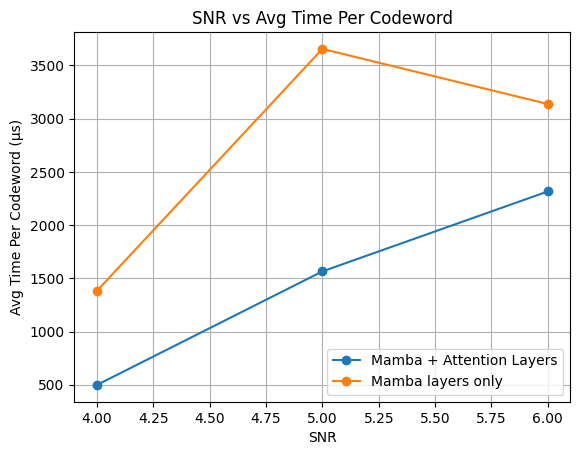

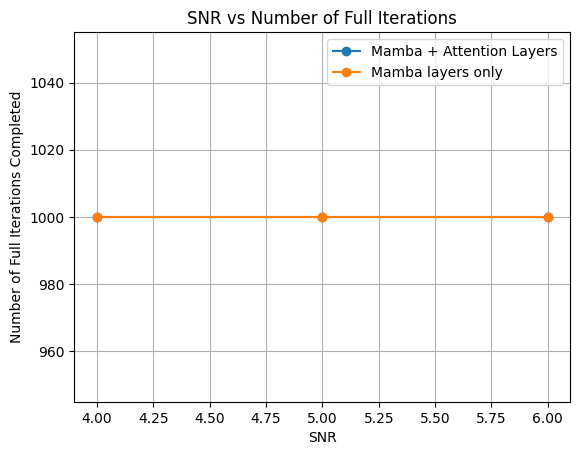

In [5]:
import json
import matplotlib.pyplot as plt

# --------- CONFIG ---------
file_1 = "./results/run_1/FB695E38DCAC256534362A7B092CCBFD/validation_hybrid_mamba_with_inf_time_no_es.json"
file_2 = "./results/run_6/FB695E38DCAC256534362A7B092CCBFD/validation_pure_mamba_with_inf_time_no_es.json"

label_1 = "Mamba + Attention Layers"
label_2 = "Mamba layers only"
# --------------------------

def load_metrics(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # The actual metrics dict is nested under the single top-level key
    metrics = next(iter(data.values()))

    snr = []
    avg_time = []
    num_iters = []

    for key, value in metrics.items():
        if key.startswith("AvgTimePerCodeword_"):
            s = int(key.split("_")[-1])
            snr.append(s)
            avg_time.append(value)
            num_iters.append(metrics.get(f"Number_Full_Iters_Completed_{s}", None))

    # Sort by SNR
    snr, avg_time, num_iters = zip(*sorted(zip(snr, avg_time, num_iters)))

    return snr, avg_time, num_iters


snr1, avg_time1, iters1 = load_metrics(file_1)
snr2, avg_time2, iters2 = load_metrics(file_2)

avg_time1 = [i*1000000 for i in avg_time1]
avg_time2 = [i*1000000 for i in avg_time2]

# --------- PLOT 1: SNR vs AvgTimePerCodeword ---------
plt.figure()
plt.plot(snr1, avg_time1, marker="o", label=label_1)
plt.plot(snr2, avg_time2, marker="o", label=label_2)
plt.xlabel("SNR")
plt.ylabel("Avg Time Per Codeword (μs)")
plt.title("SNR vs Avg Time Per Codeword")
plt.legend()
plt.grid(True)
plt.show()

# --------- PLOT 2: SNR vs Number of Full Iterations ---------
plt.figure()
plt.plot(snr1, iters1, marker="o", label=label_1)
plt.plot(snr2, iters2, marker="o", label=label_2)
plt.xlabel("SNR")
plt.ylabel("Number of Full Iterations Completed")
plt.title("SNR vs Number of Full Iterations")
plt.legend()
plt.grid(True)
plt.show()